0.4544932263


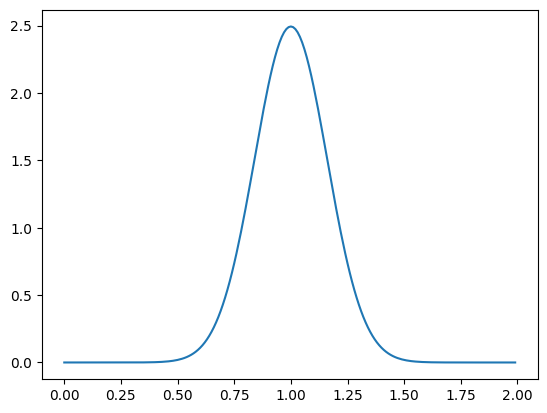

In [15]:
from matrix import*  
from solver import Newmarksuper_HSI2,accdyn_super,Newmarkpseudo_HSI2
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np
from scipy.stats import norm
from pseudo_excitation import*
from ZIV_SM import compute_subharmonic_dlf, compute_dlf

length = 60  # L - Length (m)
width = 2.7  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2.17 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 2091.8  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 1

#ped
numped = 1
pedmass = 73.85    #kg
peddamp = .29    
#pedstiff = 25000 #N/m
pedpace  = 2.17     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.38
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]
'''
Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


N_bridge = 1

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)
'''

# probabilitstic parameters
mean_pace = 2.17 #Hz  2005 pachi
pace_COV = 0.1

pace = mean_pace
mean_DLF1 = -0.2649*pace**3 +1.3206*pace**2-1.7597*pace+0.7613
print(mean_DLF1)

t = np.array(np.arange(0, (60+1) / 1.38, 0.01)) 

DLF2 = 0.07
DLF3 = 0.05
DLF4 = 0.05
DLF5 = 0.03 
DLF=np.array([mean_DLF1, DLF2, DLF3, DLF4, DLF5])

STD_DLF2 = 0.03
STD_DLF3 = 0.02
STD_DLF4 = 0.02
STD_DLF5 = 0.015


""" Data from the table for Harmonics Zivanovic and Pavic (2007)"""
i_values = [1, 2, 3, 4, 5]
a_i1_values = [0.785200, 0.513000, 0.390800, 0.325500, 0.280600]
b_i1_values = [0.999900, 2.000000, 3.000000, 4.000000, 4.999000]
c_i1_values = [0.008314, 0.011050, 0.009560, 0.008797, 0.007939]

a_i2_values = [0.020600, 0.133000, 0.156700, 0.164700, 0.158400]
b_i2_values = [1.034000, 1.957000, 3.000000, 4.001000, 5.004000]
c_i2_values = [0.252400, 0.263200, 0.055250, 0.066410, 0.078250]

a_i3_values = [0.107400, -0.049840, 0.068660, 0.068880, 0.072890]
b_i3_values = [1.001000, 1.882000, 2.957000, 3.991000, 4.987000]
c_i3_values = [0.036530, 0.058070, 0.560700, 0.375000, 0.450100]



""" Data from the table for Sub Harmonics Zivanovic and Pavic (2007)"""
a_s_i1_values = [0.340600, 0.302400, 0.262700, 0.234400, 0.264500]
b_s_i1_values = [0.498800, 1.500000, 2.500000, 3.501000, 4.499000]
c_s_i1_values = [0.008337, 0.008735, 0.009748, 0.009898, 0.010190]
a_s_i2_values = [0.280300, 0.134500, 0.245600, 0.235500, 0.238900]
b_s_i2_values = [1.133000, 1.532000, 0.231200, -1.576000, 1.153000]
c_s_i2_values = [0.638800, 0.723300, 2.932000, 7.050000, 4.561000]



x1 = np.arange(0, 2, 0.01) #multilpication factor transforming mean DLF into the distribution of DLF
pdf = norm.pdf(x1,1, 0.16)
#DLF1 = mean_DLF1*pdf
plt.plot(x1, pdf)
plt.show()

DLF_s_1= 0.026*mean_DLF1 + 0.0031
DLF_s_2= 0.074*mean_DLF1 + 0.01   
DLF_s_3= 0.012*mean_DLF1 + 0.016
DLF_s_4= 0.013*mean_DLF1 + 0.0093
DLF_s_5= 0.015*mean_DLF1 + 0.0072

DLF_s = np.array([DLF_s_1, DLF_s_2, DLF_s_3, DLF_s_4, DLF_s_5])

<Figure size 1040x715 with 0 Axes>

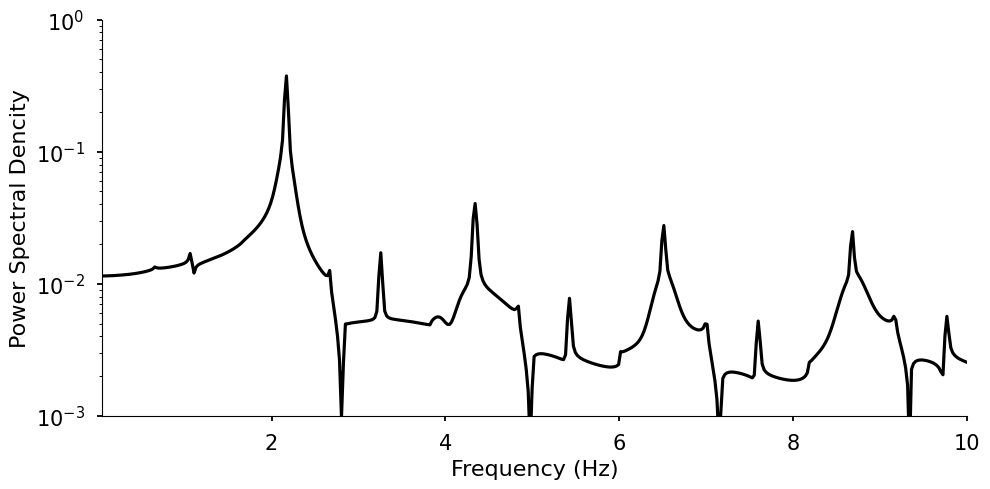

In [17]:
f_values = [pace, 2*pace, 3*pace, 4*pace, 5*pace]
i_values = [1,2,3,4,5]
dlf_values = []
x = np.linspace(0, 10, 1000)
sin = np.zeros(t.size)

for i in range(np.size(i_values)):
    f = f_values[i]
    f_range = np.arange(f - 0.5, f + 0.5,1/80)

    dlf_values = [compute_dlf(f_val, i,pace) for f_val in f_range]
    for k in range(np.size(f_range)):
        sin += dlf_values[k]*np.sin(2*np.pi*f_range[k]*t)*DLF[i]

    f_range2 = np.arange(f - 1.5, f - 0.5, 1/80)  # Adjust the step size as needed
    dlf_values2 = [compute_subharmonic_dlf(f_val, i,pace) for f_val in f_range2]

    for k in range(np.size(f_range2)):
        sin += dlf_values2[k]*np.sin(2*np.pi*f_range2[k]*t)*DLF_s[i]
sin = sin   # Remove the mean to center the signal
# Compute the FFT
N = len(sin)
T = t[1] - t[0]  # Sampling interval
fft_values = np.fft.fft(sin)
fft_freq = np.fft.fftfreq(N, T)

# Get the single-sided spectrum
fft_values = fft_values[:N//2]
fft_freq = fft_freq[:N//2]
fft_magnitude = np.abs(fft_values) / N

# Filter frequencies less than 10 Hz
mask = fft_freq < 10
filtered_freq = fft_freq[mask]
filtered_magnitude = fft_magnitude[mask]

from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10#10
plt.rcParams['axes.labelsize'] = 16#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16#8
plt.rcParams['xtick.labelsize'] = 15#8
plt.rcParams['ytick.labelsize'] = 15#8
plt.rcParams['legend.fontsize'] = 12#10
plt.rcParams['figure.titlesize'] = 15#12
rc('text', usetex=False)
# Plot the single-sided FFT
plt.figure()
# Create a figure with a specific aspect ratio (width, height)
fig, ax = plt.subplots(figsize=(10, 5))  # Aspect ratio 2:
plt.semilogy(filtered_freq, filtered_magnitude*2, color='black')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Dencity")
# Set y‐axis from 1e‐4 to 1e0
ax.set_ylim(1e-3, 1e0)
ax.set_xlim(0.05, 10)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig("ZIVSM PSD5", format='pdf', dpi=300)
plt.show()   



<Figure size 1040x715 with 0 Axes>

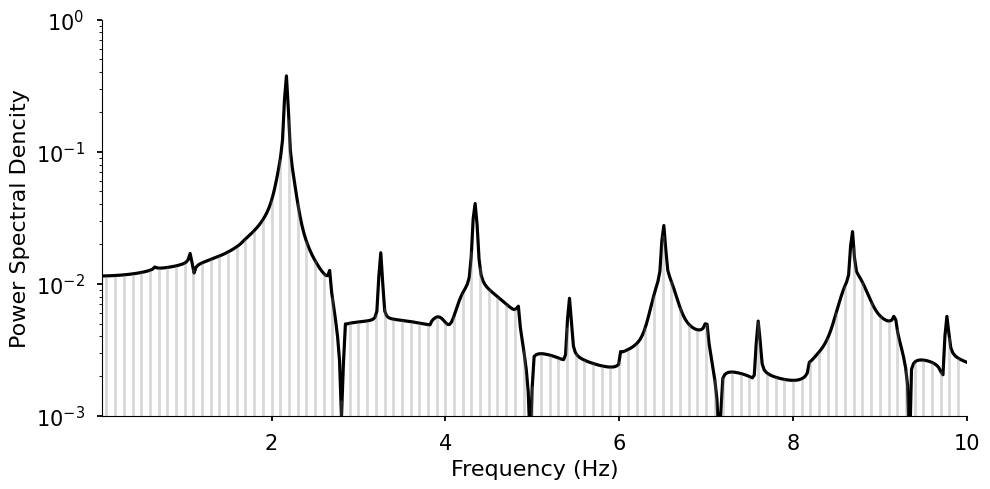

In [19]:
from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10#10
plt.rcParams['axes.labelsize'] = 16#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16#8
plt.rcParams['xtick.labelsize'] = 15#8
plt.rcParams['ytick.labelsize'] = 15#8
plt.rcParams['legend.fontsize'] = 12#10
plt.rcParams['figure.titlesize'] = 15#12
rc('text', usetex=False)
# Plot the single-sided FFT
plt.figure()
# Create a figure with a specific aspect ratio (width, height)
fig, ax = plt.subplots(figsize=(10, 5))  # Aspect ratio 2:
plt.semilogy(filtered_freq, filtered_magnitude*2, color='black')
# After your semilogy plot:
y_vals = filtered_magnitude * 2  # or whatever your plotted data is

# Add vertical lines every 0.1 Hz up to the curve
x_lines = np.arange(0, filtered_freq.max(), 0.1)
for x0 in x_lines:
    y0 = np.interp(x0, filtered_freq, y_vals)
    plt.vlines(x0, ymin=0, ymax=y0,
               colors='gray', linestyles='-', alpha=0.3, linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Dencity")
ax.set_ylim(1e-3, 1e0)
ax.set_xlim(0.05, 10)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("ZIVSM PSD with vertical lines", format='pdf', dpi=300)
plt.show()   







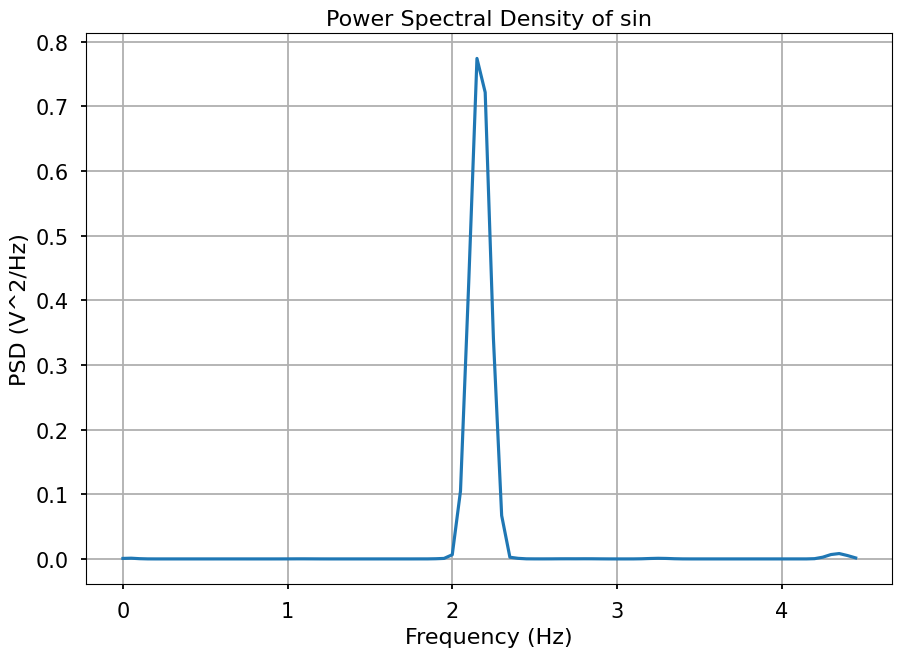

In [53]:
from scipy.signal import welch
from matplotlib import rc
rc('text', usetex=False)

# Compute the PSD of the sin signal
fs = 1 / (t[1] - t[0])  # Sampling frequency
frequencies, psd = welch(sin, fs=fs,nperseg=1000, nfft=2000 )
frequencies = np.array(frequencies)
psd = np.array(psd)
frequencies=frequencies[frequencies<(4.5)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]

# Plot the PSD
plt.figure()
plt.plot(frequencies, psd)
plt.title("Power Spectral Density of sin")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V^2/Hz)")
plt.grid(True)
plt.show()

DLF variation for f=2.17 (from 1.92 to 2.42):
f=1.67, DLF=0.0069
f=1.68, DLF=0.0072
f=1.69, DLF=0.0075
f=1.71, DLF=0.0079
f=1.72, DLF=0.0083
f=1.73, DLF=0.0086
f=1.74, DLF=0.0090
f=1.76, DLF=0.0094
f=1.77, DLF=0.0097
f=1.78, DLF=0.0101
f=1.79, DLF=0.0105
f=1.81, DLF=0.0109
f=1.82, DLF=0.0113
f=1.83, DLF=0.0117
f=1.84, DLF=0.0121
f=1.86, DLF=0.0125
f=1.87, DLF=0.0129
f=1.88, DLF=0.0133
f=1.89, DLF=0.0137
f=1.91, DLF=0.0141
f=1.92, DLF=0.0145
f=1.93, DLF=0.0149
f=1.94, DLF=0.0153
f=1.96, DLF=0.0157
f=1.97, DLF=0.0162
f=1.98, DLF=0.0168
f=1.99, DLF=0.0175
f=2.01, DLF=0.0185
f=2.02, DLF=0.0201
f=2.03, DLF=0.0226
f=2.04, DLF=0.0262
f=2.06, DLF=0.0316
f=2.07, DLF=0.0390
f=2.08, DLF=0.0488
f=2.09, DLF=0.0608
f=2.11, DLF=0.0746
f=2.12, DLF=0.0896
f=2.13, DLF=0.1143
f=2.14, DLF=0.2344
f=2.16, DLF=0.6178
f=2.17, DLF=0.9126
f=2.18, DLF=0.6037
f=2.19, DLF=0.2306
f=2.21, DLF=0.1185
f=2.22, DLF=0.0955
f=2.23, DLF=0.0808
f=2.24, DLF=0.0668
f=2.26, DLF=0.0543
f=2.27, DLF=0.0440
f=2.28, DLF=0.0360
f=2.

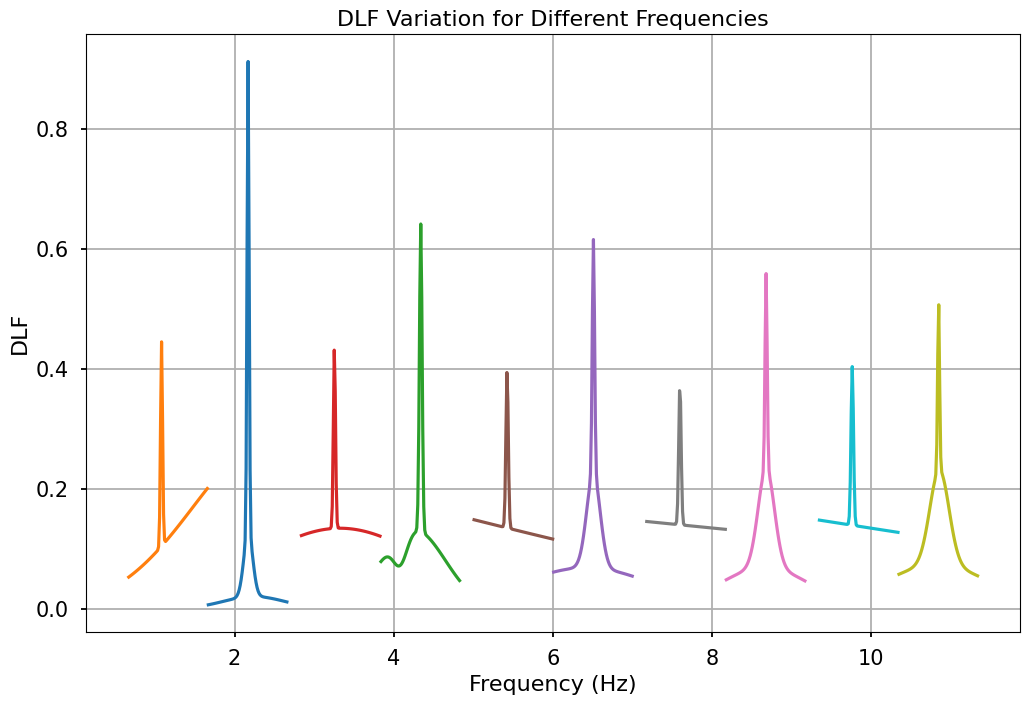

In [54]:

fp=2.17

# Define the f values and the range for DLF calculation
f_values = [fp, 2*fp, 3*fp, 4*fp, 5*fp]
dlf_values = []
x = np.arange(0, 10, 1/80)

# Iterate over each f value and compute the DLF in the range [f-0.25, f+0.25]
for i in range(np.size(i_values)):
    f = f_values[i]
    f_range = np.arange(f - 0.5, f + 0.5, 1/80)  # Adjust the step size as needed
    dlf_values = [compute_dlf(f_val, i,fp) for f_val in f_range]
   # pdf = norm.pdf(f_range, f_values[i], 0.1)
    #dlf_values = pdf*dlf_values

    f_range2 = np.arange(f - 1.5, f - 0.5, 1/80)  # Adjust the step size as needed
    dlf_values2 = [compute_subharmonic_dlf(f_val, i,fp) for f_val in f_range2]
    #pdf2 = norm.pdf(f_range2, f_values[i]-1, 0.1)
    #dlf_values2 = pdf2*dlf_values2

    # Print the results
    print(f"DLF variation for f={f} (from {f-0.25} to {f+0.25}):")
    for f_val, dlf_val in zip(f_range, dlf_values):
        print(f"f={f_val:.2f}, DLF={dlf_val:.4f}")
    print()  # Add a blank line for better readability

    plt.plot(f_range, dlf_values, label=f'DLF f={f}')
    plt.plot(f_range2, dlf_values2, label=f'Subharmonic DLF f={f}')


# Customize the plot
plt.title("DLF Variation for Different Frequencies")
plt.xlabel("Frequency (Hz)")
plt.ylabel("DLF")
#plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

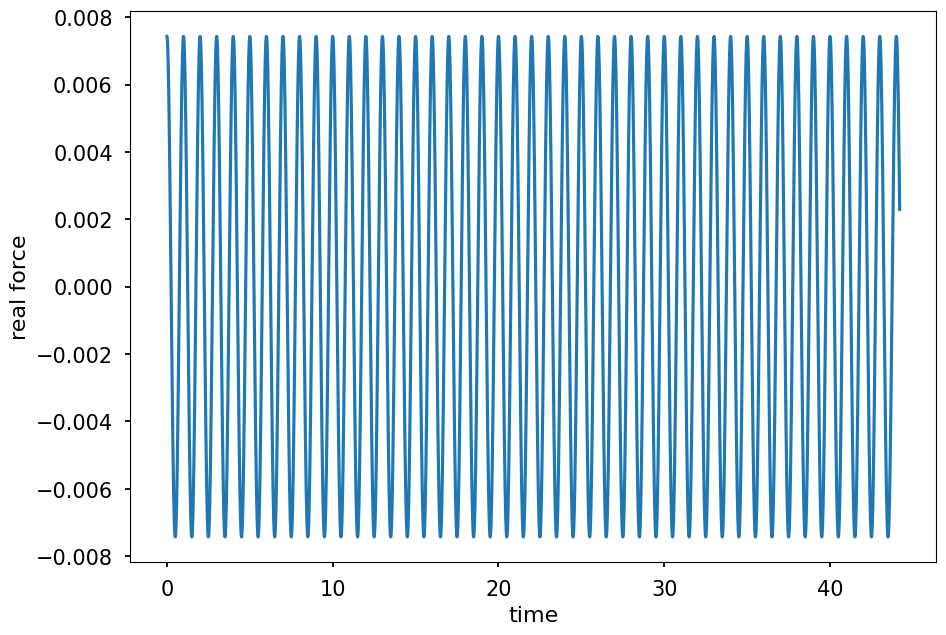

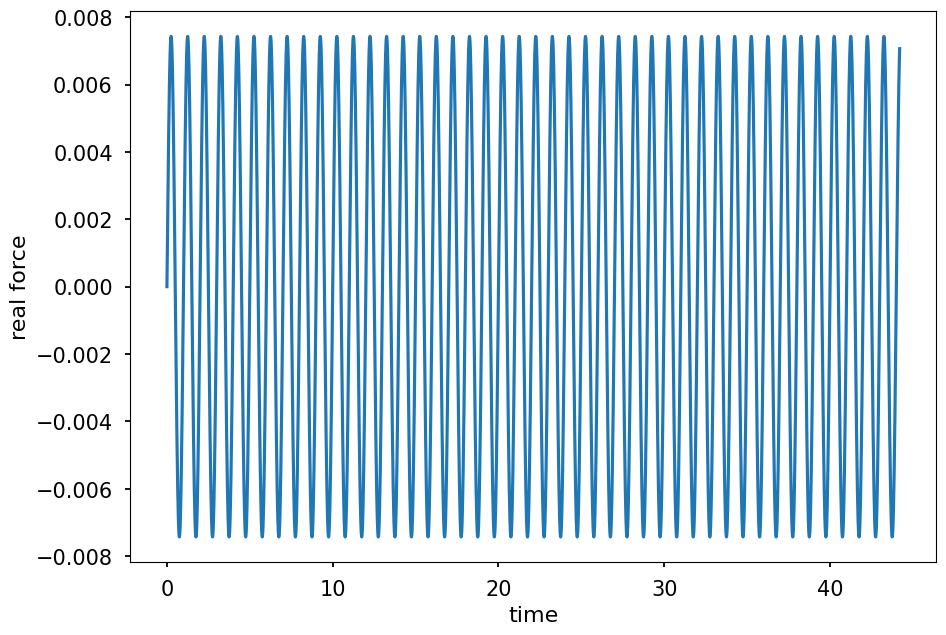

In [55]:
real,imaginary = pseudo_excitation(psd,frequencies,60,1.38,t,)
plt.plot(t.flatten(),real[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()


[[ 0.00000000e+00  2.34133402e-08  9.31455603e-08 ... -1.84733444e-01
  -1.78490545e-01  0.00000000e+00]
 [ 0.00000000e+00  7.68989066e-16  1.89160433e-14 ...  1.68285056e-01
   1.76553992e-01  0.00000000e+00]]
[[ 0.00000000e+00  2.80488787e-08  1.11586623e-07 ... -8.46615123e-02
  -8.20089377e-02  0.00000000e+00]
 [ 0.00000000e+00  9.21238952e-16  2.26611025e-14 ...  7.62017722e-02
   8.02102652e-02  0.00000000e+00]]
[[ 0.00000000e+00  1.64508469e-08  6.54452948e-08 ...  3.01173515e-02
   2.90556215e-02  0.00000000e+00]
 [ 0.00000000e+00  5.40312542e-16  1.32907538e-14 ... -2.76243826e-02
  -2.89259741e-02  0.00000000e+00]]
[[ 0.00000000e+00  5.60608400e-09  2.23017529e-08 ... -4.70767337e-03
  -4.55007612e-03  0.00000000e+00]
 [ 0.00000000e+00  1.84126539e-16  4.52912169e-15 ...  4.28828695e-03
   4.50086991e-03  0.00000000e+00]]
[[ 0.00000000e+00  7.73053859e-11  3.07520501e-10 ... -4.32293520e-05
  -4.15511979e-05  0.00000000e+00]
 [ 0.00000000e+00  2.53902245e-18  6.24531563e-17 .

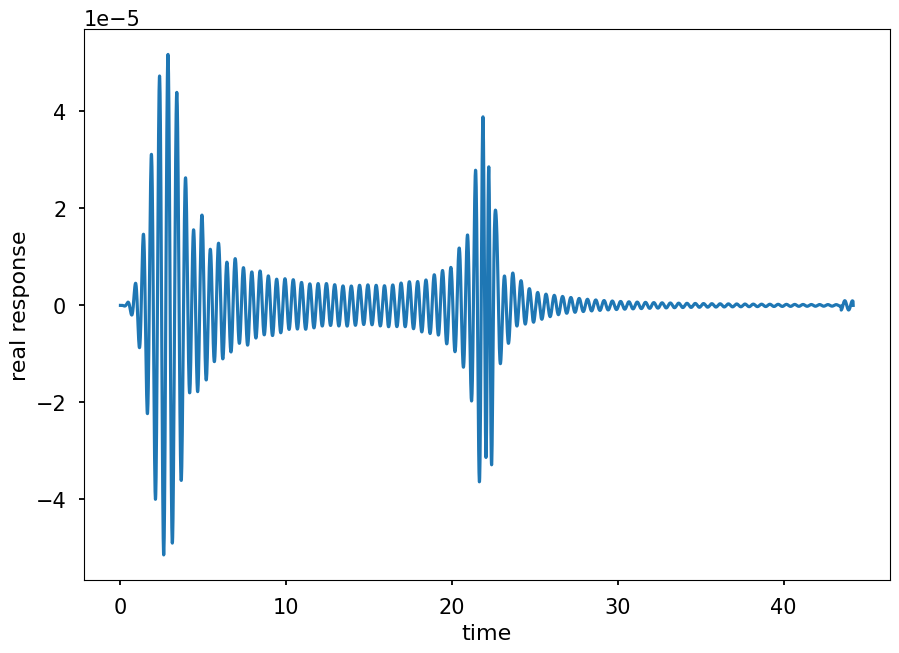

In [56]:
Real_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)

In [30]:
import pickle
with open('Real_responce_ZIV_SM_eg.pkl', 'wb') as f:
    pickle.dump(Real_responce, f)

print("Matrix saved to Real_responce_ZIV_SM_eg.pkl")

Matrix saved to Real_responce_ZIV_SM_eg.pkl


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[ 0.00000000e+00  0.00000000e+00  3.52309813e-10 ...  1.65086463e-01
   1.59300695e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  4.62638326e-17 ... -1.51345352e-01
  -1.58519902e-01  0.00000000e+00]]
[[ 0.00000000e+00  0.00000000e+00  4.13261882e-10 ... -1.56198535e-02
  -1.50714635e-02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  5.42678000e-17 ...  1.43072223e-02
   1.49843329e-02  0.00000000e+00]]
[[ 0.00000000e+00  0.00000000e+00  2.11243997e-10 ...  7.31564208e-03
   7.04699815e-03  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.77396670e-17 ... -6.75932454e-03
  -7.06424574e-03  0.00000000e+00]]
[[ 0.00000000e+00  0.00000000e+00  3.88390201e-12 ... -7.57057640e-05
  -7.31528858e-05  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  5.10017562e-19 ...  6.90215756e-05
   7.24204320e-05  0.00000000e+00]]
[[ 0.00000000e+00  0.00000000e+00  5.01234194e-11 ... -1.79520224e-04
  -1.72042120e-04  0.00000000e+00]


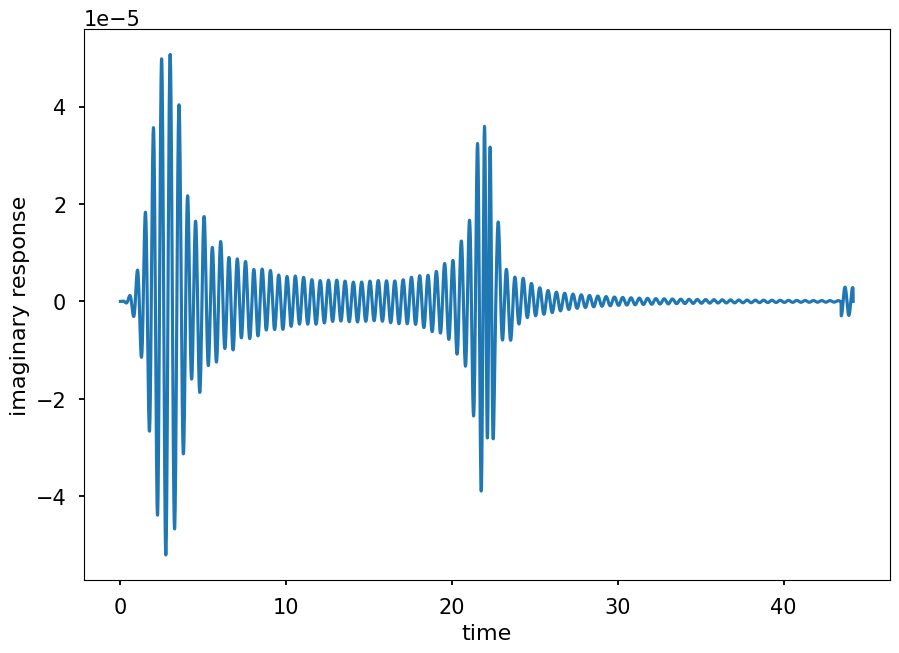

In [57]:
imag_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)



plt.plot(t.flatten(),imag_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)   


In [32]:
import pickle
with open('imag_responce_ZIV_SM_eg.pkl', 'wb') as f:
    pickle.dump(imag_responce, f)

print("Matrix saved to imag_responce_ZIV_SM_eg.pkl")

Matrix saved to imag_responce_ZIV_SM_eg.pkl


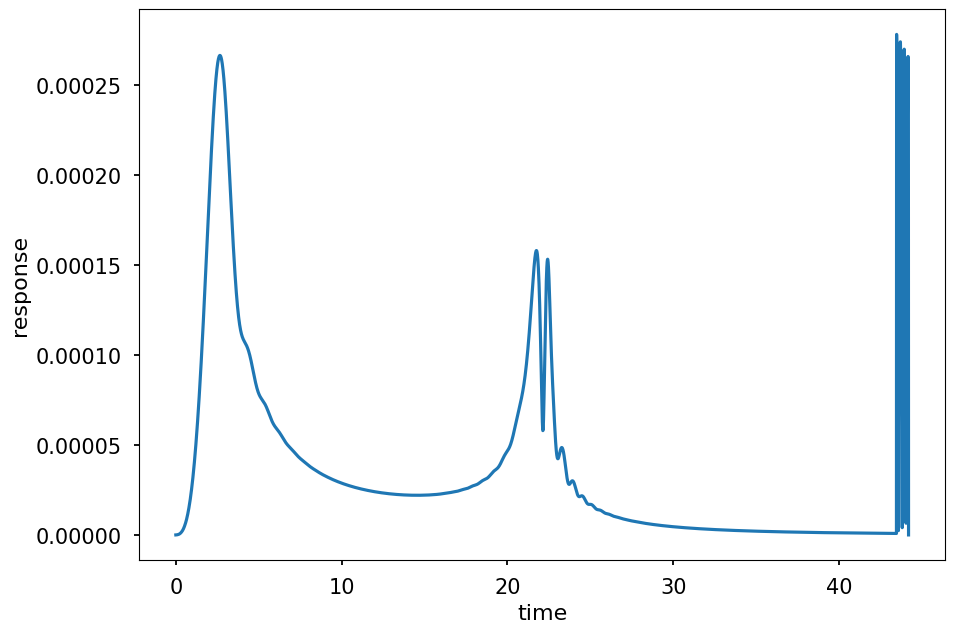

In [58]:
with open('Real_responce_ZIV_SM_eg.pkl', 'rb') as f1:
    Real_responce = pickle.load(f1)
with open('imag_responce_ZIV_SM_eg.pkl', 'rb') as f2:
    imag_responce = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies)):
        Y[0,[i]] += (Real_responce[[j],[i]]**2 + imag_responce[[j],[i]]**2)*delta_f

deterministic_RMS=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(t.flatten(),deterministic_RMS.T)
plt.xlabel("time")
plt.ylabel("response")

plt.show()

In [83]:
import pickle
with open('ZIV_SM_withHSI.pkl', 'wb') as f:
    pickle.dump(deterministic_RMS, f)

print("Matrix saved to ZIV_SM_withHSI.pkl")

Matrix saved to ZIV_SM_withHSI.pkl


In [37]:
# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(deterministic_RMS)

# Print the maximum RMS value and its corresponding time
print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")


Maximum 0.5-second RMS value: 0.0002 m/s^2 
